# GEOG5990M Final Assignment - RESIT

Student ID number: <font color = red>[202021408]</font>

### Assignment Details

This assignment should use this Jupyter Notebook to document the investigation and interpretation of the relationship between AirBNB property rentals and area characteristics (data provided) in Bristol.

A full overview of the data provided can be found below.

These data should be suitably joined and pre-processed to provide insight and two polished data visualisations produced to communicate the results of the analysis.

- The Jupyter notebook should follow the data science process outlined in the module.
- You should use markdown cells to explain and justify the steps taken in the code.
- Whilst you should use visualisations throughout for data exploration, please present two final visualisations to communicate your ‘public good’ insight, one spatial and one non-spatial.
- For both these visualisations indicate your intended audience (e.g. academic, the public, policymakers, business stakeholders)
- AND the subsequent data visualisation choices that have been made to ensure these outputs are suitable for this audience.


The Jupyter notebook <b>markdown word count</b> is limited to <b>1500 words.</b>    

Please upload the Jupyter Notebook and all files need to run the notebook analysis as a zip file using the 'Zip file upload' option of Turnitin. Contained within the zip folder please also submit a .txt file with a link to your GitHub repository

### Assessment Information

##### You will be assessed on the following:

- **Readability of the Jupyter notebook including markdown cells and commented code (5%)**
- **Logical Flow of the Jupyter notebook (5%)**
- **Data cleaning (30%), including:**
    -  Exploratory data description (with citations where appropriate)
    - Justification of data cleaning choices (with citations where appropriate)
    - Data visualisation to aid data cleaning
- **Statistical modelling/ quantification of the association between your chosen variables (10%):**
    - Effective interpretation of the model
    - Justification of model chosen
    - Potential models include: k-means, spearman’s rank, predictive model (e.g. OLS)
- **Data Visualisation of end results: (30%)**
    - This should include one spatial and one non-spatial visualisation
    - Evidence of modifying visualisations to make them:
        - Accessible (colour blind audience etc.)
        - Easy to interpret
        - Readable (e.g. change variable names from how they have been presented in original table to improve understanding)
    - Explanation of data visualisation choices (with citations where appropriate)
    - Evidence of critical selection of chosen visualisations to present (with citations where appropriate)
- **Reproducibility (20%)**
    - You should ensure all the data and steps to produce the analysis undertaken is reproducible
    - You should create a <font color = red><b>GitHub repository with suitable documentation</b></font>. This should include an introductory markdown (readme) file explaining:
        -  The background/context of the project
        -  What data the GitHub repository contains
        -  What the code aims to do
        -  Any further information someone might need to be able to run your code and reproduce your analysis
    -  All files needed to run the analysis
    -  Your .ipynb notebook


The Jupyter notebook will be marked against the SoG generic marking criteria and specifically the following additional criteria:
- Understanding of task
- Structure and flow of the report
- Breadth of content
- Reading and referencing
- Aesthetics and design
- Writing / presentation
- Data


## Data Overview
### AirBNB  data
A sample of AirBNB data for Bristol has been collected for you.
AirBNB is a company operating that operates an online marketplace for short- and long-term homestays and experiences. It is often used to book holiday stays. The data provided includes...


| Field | Description |
|---|---|
| id | Airbnb's unique identifier for the listing |
| name |  |
| host_id |  |
| host_name |  |
| neighbourhood_group | The neighbourhood group as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles. |
| neighbourhood | The neighbourhood as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles. |
| latitude | Uses the World Geodetic System (WGS84) projection for latitude and longitude. |
| longitude | Uses the World Geodetic System (WGS84) projection for latitude and longitude. |
| price | daily price in local currency. Note, $ sign may be used despite locale |
| minimum_nights | minimum number of night stay for the listing (calendar rules may be different) |
| number_of_reviews | The number of reviews the listing has |
| last_review | The date of the last/newest review |
| calculated_host_listings_count | The number of listings the host has in the current scrape, in the city/region geography. |
| availability_365 | avaliability_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may be available because it has been booked by a guest or blocked by the host. |
| number_of_reviews_ltm | The number of reviews the listing has (in the last 12 months) |
| license |  |
| property_type | Self selected property type. Hotels and Bed and Breakfasts are described as such by their hosts in this field |
| room_type | All homes are grouped into the following three room types: Entire place, Private room, Shared room, Hotel |
| accommodates | The maximum capacity of the listing |
| bathrooms | The number of bathrooms in the listing |
| bathrooms_text | The number of bathrooms in the listing.  On the Airbnb web-site, the bathrooms field has evolved from a number to a textual description. For older scrapes, bathrooms is used. |
| bedrooms | The number of bedrooms |
| beds | The number of bed(s) |
| amenities |  |


### Access to Healthy Assets and Hazards (AHAH) Data

AHAH (the index of ‘Access to Health Assets and Hazards’) is a multi-dimensional index developed by the CDRC for Great Britain measuring how ‘healthy’ neighbourhoods are. The AHAH index combines indicators under four different domains of accessibility:

- Retail environment (access to fast food outlets, pubs, tobacconists, gambling outlets),
- Health services (access to GPs, hospitals, pharmacies, dentists, leisure services),
- Physical environment (Blue Space, Green Space - Passive), and
- Air quality (NO₂, PM10, SO₂).

Please look at the full AHAH metadata on the CDRC website, make sure you understand what each of the variables are showing you
https://data.geods.ac.uk/dataset/access-to-healthy-assets-hazards-ahah

In [ ]:
# read in required packages
import pandas as pd
import geopandas as gpd

1.Introduce


Airbnb has become the industry leader of point-to-point accommodation platforms over the past decade and has become a model of the sharing economy <a href="#ref1">[1]</a>. For landlords, short-term tourism rentals are often more profitable than long-term residential rentals. For guests, using Airbnb allows them to experience the accommodation environment, interact with the landlord, and engage with the local culture <a href="#ref2">[2]</a>. The listings are often concentrated in regions with more abundant tourism resources <a href="#ref3">[3]</a>.

When policymakers design policies, they are increasingly paying attention to the impact of geographical environment on health <a href="#ref4">[4]</a>. AHAH was created for the UK to develop a national open-source low-level geographical indicator, used to measure whether the surrounding environment of each community is beneficial to health. When AHAH was developed, 14 indicators were considered, divided into 4 categories, and the average score and comprehensive score of each neighborhood were calculated, providing reference and assistance for policymakers and researchers <a href="#ref5">[5]</a>.

Bristol is one of the most popular tourist destinations in the UK, which has led to the rapid development of the sharing economy platforms in the short-term rental property market <a href="#ref3">[3]</a>.

In [ ]:
# read in the final project resit files

# read in AirBnB Data
airbnb =pd.read_csv('https://github.com/FrancescaPontin/GEOG5990M_final_project_resit/raw/refs/heads/main/airbnb_data_bristol.csv')
# read in AHAH index data
ahah = gpd.read_file('https://github.com/FrancescaPontin/GEOG5990M_final_project_resit/raw/refs/heads/main/bristol_ahah_index.geojson')

In [ ]:
# View the first five rows of the AHAH data
ahah.head()

,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,lsoa11,...,ah3e_rnk,ah3r_rnk,ah3h_pct,ah3g_pct,ah3e_pct,ah3r_pct,ah3ahah,ah3ahah_rn,ah3ahah_pc,geometry
0,14053,E01014485,Bristol 023A,Bristol 023A,360020,174735,-2.57697,51.47015,3edee4ae-aa59-4e9e-8066-fd81222d4d4d,E01014485,...,33816,31832,30,80,82,77,28.100961,33416,81,"POLYGON ((-2.56785 51.46891, -2.57002 51.46804..."
1,14054,E01014486,Bristol 023B,Bristol 023B,359924,174186,-2.57829,51.46521,756ec26e-f1c8-4911-ad30-ff9aab76e295,E01014486,...,33949,35387,13,67,82,85,26.761410,32088,77,"POLYGON ((-2.5736 51.46692, -2.57992 51.4619, ..."
2,14055,E01014487,Bristol 020A,Bristol 020A,359244,174738,-2.58814,51.47013,3b905c75-f6aa-42c6-8347-f96f779a7b75,E01014487,...,31217,35558,24,79,75,86,28.393144,33716,81,"POLYGON ((-2.58707 51.47168, -2.58391 51.47269..."
3,14056,E01014488,Bristol 023C,Bristol 023C,359701,174621,-2.58155,51.46911,266e675c-152b-4827-abb0-c9424d7b485f,E01014488,...,34627,32437,17,49,83,78,22.955942,26901,65,"POLYGON ((-2.58002 51.4697, -2.57762 51.46883,..."
4,14057,E01014489,Bristol 023D,Bristol 023D,359346,174262,-2.58662,51.46585,b608a9d9-8976-4047-b4c5-a5dbf541d1ac,E01014489,...,33597,36565,5,83,81,88,30.566093,35495,86,"POLYGON ((-2.58258 51.4671, -2.58309 51.46534,..."


In [ ]:
## explore the AHAH spatial data
ahah.explore()

In [ ]:
#View the first five rows of the Airbnb dataset
airbnb.head()

,Unnamed: 0,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type_x,...,license,property_type,room_type_y,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,LSOA11CD
0,0,70820,Townhouse in Bristol · ★4.77 · 1 bedroom · 1 b...,360195,Sarah,NaN,Windmill Hill,51.43843,-2.59183,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1 shared bath,NaN,1.0,[],E01014734
1,1,117122,Condo in Bristol · ★4.96 · 1 bedroom · 1 bed ·...,591555,Marcus,NaN,Hotwells & Harbourside,51.44976,-2.61000,Private room,...,NaN,Private room in condo,Private room,2,NaN,2.5 shared baths,NaN,1.0,[],E01033350
2,2,176306,Townhouse in Bristol · ★4.79 · 1 bedroom · 1 b...,708175,Orla,NaN,Southville,51.44174,-2.60297,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1 shared bath,NaN,1.0,[],E01014698
3,3,307634,Townhouse in Bristol · ★4.65 · 1 bedroom · 1 b...,1582810,Wendy,NaN,Easton,51.46487,-2.55690,Private room,...,NaN,Private room in townhouse,Private room,2,NaN,1.5 shared baths,NaN,1.0,[],E01014570
4,4,390781,Home in Bristol · ★4.89 · 1 bedroom · 1 bed · ...,1954565,Fiona,NaN,Brislington West,51.44444,-2.55783,Private room,...,NaN,Private room in home,Private room,1,NaN,1 shared bath,NaN,1.0,[],E01014531


In [ ]:
## view the columns in the Airbnb
airbnb.columns

Index(['Unnamed: 0', 'id', 'name', 'host_id', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type_x', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'property_type',
       'room_type_y', 'accommodates', 'bathrooms', 'bathrooms_text',
       'bedrooms', 'beds', 'amenities', 'LSOA11CD'],
      dtype='object')

In [ ]:
# check the shape of the Airbnb dataset
airbnb.shape

(2556, 28)

In [ ]:
# check the data types in the Airbnb dataset
airbnb.dtypes

,0
Unnamed: 0,int64
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,float64
neighbourhood,object
latitude,float64
longitude,float64
room_type_x,object


In [ ]:
# check the Airbnb dataset for missing data
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556 entries, 0 to 2555
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      2556 non-null   int64  
 1   id                              2556 non-null   int64  
 2   name                            2556 non-null   object 
 3   host_id                         2556 non-null   int64  
 4   host_name                       2556 non-null   object 
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   2556 non-null   object 
 7   latitude                        2556 non-null   float64
 8   longitude                       2556 non-null   float64
 9   room_type_x                     2556 non-null   object 
 10  price                           2169 non-null   float64
 11  minimum_nights                  2556 non-null   int64  
 12  number_of_reviews               25

In [ ]:
# count missing values in the Airbnb dataset
airbnb.isnull().sum()

,0
Unnamed: 0,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,2556
neighbourhood,0
latitude,0
longitude,0
room_type_x,0


In [ ]:
# view the Airbnb listing with missing LSOA code
airbnb.loc[airbnb['LSOA11CD'].isna()]

,Unnamed: 0,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type_x,...,license,property_type,room_type_y,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,LSOA11CD
2139,2139,930212420101313369,Home in Pill · 2 bedrooms · 3 beds · 0 baths,247416919,Sykes Holiday Cottages,NaN,Avonmouth & Lawrence Weston,51.482034,-2.682301,Entire home/apt,...,NaN,Entire home,Entire home/apt,4,NaN,0 baths,NaN,3.0,[],NaN


In [ ]:
# view the columns in the AHAH dataset
ahah.columns

Index(['FID', 'LSOA11CD', 'LSOA11NM', 'LSOA11NMW', 'BNG_E', 'BNG_N', 'LONG',
       'LAT', 'GlobalID', 'lsoa11', 'ah3gp', 'ah3dent', 'ah3phar', 'ah3hosp',
       'ah3blue', 'ah3gpas', 'ah3ffood', 'ah3gamb', 'ah3leis', 'ah3pubs',
       'ah3tob', 'ah3no2', 'ah3so2', 'ah3pm10', 'ah3gp_rnk', 'ah3dent_rnk',
       'ah3phar_rnk', 'ah3hosp_rnk', 'ah3leis_rnk', 'ah3gpas_rnk',
       'ah3blue_rnk', 'ah3no2_rnk', 'ah3so2_rnk', 'ah3pm10_rnk', 'ah3gamb_rnk',
       'ah3pubs_rnk', 'ah3tob_rnk', 'ah3ffood_rnk', 'ah3gp_pct', 'ah3dent_pct',
       'ah3phar_pct', 'ah3hosp_pct', 'ah3leis_pct', 'ah3gpas_pct',
       'ah3blue_pct', 'ah3no2_pct', 'ah3so2_pct', 'ah3pm10_pct', 'ah3gamb_pct',
       'ah3pubs_pct', 'ah3tob_pct', 'ah3ffood_pct', 'ah3h', 'ah3g', 'ah3e',
       'ah3r', 'ah3h_rnk', 'ah3g_rnk', 'ah3e_rnk', 'ah3r_rnk', 'ah3h_pct',
       'ah3g_pct', 'ah3e_pct', 'ah3r_pct', 'ah3ahah', 'ah3ahah_rn',
       'ah3ahah_pc', 'geometry'],
      dtype='object')

In [ ]:
# check the shape of the AHAH dataset
ahah.shape

(263, 68)

In [ ]:
# check the data types in the AHAH dataset
ahah.dtypes

,0
FID,int32
LSOA11CD,object
LSOA11NM,object
LSOA11NMW,object
BNG_E,int32
...,...
ah3r_pct,int32
ah3ahah,float64
ah3ahah_rn,int32
ah3ahah_pc,int32


In [ ]:
# check the AHAH dataset for missing data
ahah.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 68 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   FID           263 non-null    int32   
 1   LSOA11CD      263 non-null    object  
 2   LSOA11NM      263 non-null    object  
 3   LSOA11NMW     263 non-null    object  
 4   BNG_E         263 non-null    int32   
 5   BNG_N         263 non-null    int32   
 6   LONG          263 non-null    float64 
 7   LAT           263 non-null    float64 
 8   GlobalID      263 non-null    object  
 9   lsoa11        263 non-null    object  
 10  ah3gp         263 non-null    float64 
 11  ah3dent       263 non-null    float64 
 12  ah3phar       263 non-null    float64 
 13  ah3hosp       263 non-null    float64 
 14  ah3blue       263 non-null    float64 
 15  ah3gpas       263 non-null    float64 
 16  ah3ffood      263 non-null    float64 
 17  ah3gamb       263 non-null    float64 
 18  ah

In [ ]:
# count missing values in the AHAH dataset
ahah.isnull().sum()

,0
FID,0
LSOA11CD,0
LSOA11NM,0
LSOA11NMW,0
BNG_E,0
...,...
ah3r_pct,0
ah3ahah,0
ah3ahah_rn,0
ah3ahah_pc,0


In [ ]:
# count Airbnb listings in each LSOA
airbnb.groupby('LSOA11CD').size()

,0
LSOA11CD,
E01014485,23
E01014486,45
E01014487,30
E01014488,17
E01014489,51
...,...
E01033364,5
E01033366,10
E01033367,25


In [ ]:
# Save the number of Airbnb listings in each LSOA
airbnb_count = airbnb.groupby('LSOA11CD').size()

In [ ]:
# view Airbnb listing counts
airbnb_count

,0
LSOA11CD,
E01014485,23
E01014486,45
E01014487,30
E01014488,17
E01014489,51
...,...
E01033364,5
E01033366,10
E01033367,25


In [ ]:
# convert Airbnb counts to a dataframe
airbnb_count = airbnb_count.reset_index(name='airbnb_count')

In [ ]:
# view Airbnb counts
airbnb_count.head()

,LSOA11CD,airbnb_count
0,E01014485,23
1,E01014486,45
2,E01014487,30
3,E01014488,17
4,E01014489,51


In [ ]:
# merge Airbnb counts with the AHAH dataset
ahah_airbnb = ahah.merge(airbnb_count, how='left', on='LSOA11CD')

In [ ]:
# view the merged dataset
ahah_airbnb.head()

,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,lsoa11,...,ah3r_rnk,ah3h_pct,ah3g_pct,ah3e_pct,ah3r_pct,ah3ahah,ah3ahah_rn,ah3ahah_pc,geometry,airbnb_count
0,14053,E01014485,Bristol 023A,Bristol 023A,360020,174735,-2.57697,51.47015,3edee4ae-aa59-4e9e-8066-fd81222d4d4d,E01014485,...,31832,30,80,82,77,28.100961,33416,81,"POLYGON ((-2.56785 51.46891, -2.57002 51.46804...",23.0
1,14054,E01014486,Bristol 023B,Bristol 023B,359924,174186,-2.57829,51.46521,756ec26e-f1c8-4911-ad30-ff9aab76e295,E01014486,...,35387,13,67,82,85,26.761410,32088,77,"POLYGON ((-2.5736 51.46692, -2.57992 51.4619, ...",45.0
2,14055,E01014487,Bristol 020A,Bristol 020A,359244,174738,-2.58814,51.47013,3b905c75-f6aa-42c6-8347-f96f779a7b75,E01014487,...,35558,24,79,75,86,28.393144,33716,81,"POLYGON ((-2.58707 51.47168, -2.58391 51.47269...",30.0
3,14056,E01014488,Bristol 023C,Bristol 023C,359701,174621,-2.58155,51.46911,266e675c-152b-4827-abb0-c9424d7b485f,E01014488,...,32437,17,49,83,78,22.955942,26901,65,"POLYGON ((-2.58002 51.4697, -2.57762 51.46883,...",17.0
4,14057,E01014489,Bristol 023D,Bristol 023D,359346,174262,-2.58662,51.46585,b608a9d9-8976-4047-b4c5-a5dbf541d1ac,E01014489,...,36565,5,83,81,88,30.566093,35495,86,"POLYGON ((-2.58258 51.4671, -2.58309 51.46534,...",51.0


In [ ]:
# check the shape of the merged dataset
ahah_airbnb.shape

(263, 69)

In [ ]:
# replace missing Airbnb counts with 0
ahah_airbnb['airbnb_count'] = ahah_airbnb['airbnb_count'].fillna(0)

In [ ]:
# convert Airbnb counts to integers
ahah_airbnb['airbnb_count'] = ahah_airbnb['airbnb_count'].astype(int)

In [ ]:
ahah_airbnb['airbnb_count'].head()

,airbnb_count
0,23
1,45
2,30
3,17
4,51


In [ ]:
# view the overall AHAH percentile
ahah_airbnb['ah3ahah_pc'].head()

,ah3ahah_pc
0,81
1,77
2,81
3,65
4,86


In [ ]:
# describe the overall AHAH percentile
ahah_airbnb['ah3ahah_pc'].describe()

,ah3ahah_pc
count,263.000000
mean,59.615970
std,23.921326
min,1.000000
25%,42.500000
50%,62.000000
75%,80.000000
max,99.000000


In [ ]:
# describe Airbnb listing counts
ahah_airbnb['airbnb_count'].describe()

,airbnb_count
count,263.000000
mean,9.714829
std,12.310799
min,0.000000
25%,2.000000
50%,6.000000
75%,11.000000
max,103.000000


<Axes: >

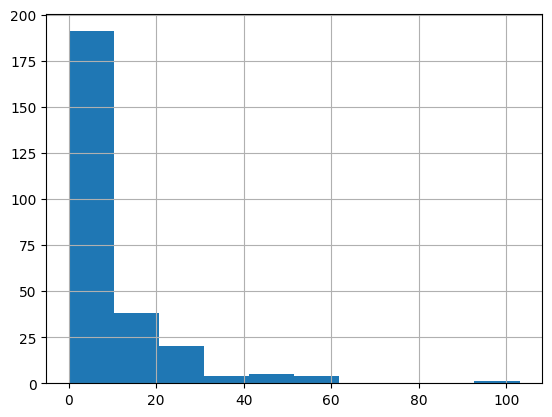

In [ ]:
# explore the distribution of Airbnb listing counts
ahah_airbnb['airbnb_count'].hist()

<Axes: xlabel='ah3ahah_pc', ylabel='airbnb_count'>

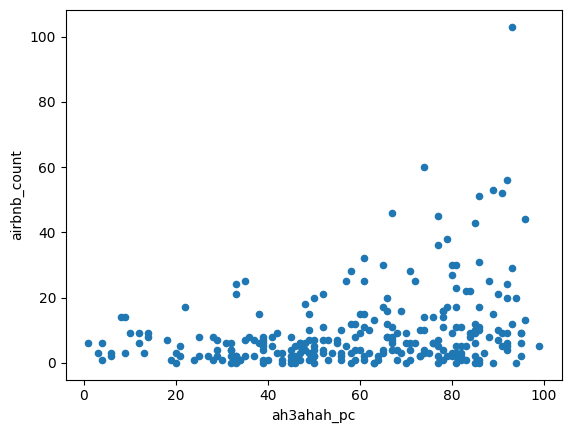

In [ ]:
# explore the relationship between Airbnb counts and overall AHAH percentile
ahah_airbnb.plot.scatter(x='ah3ahah_pc', y='airbnb_count')

In [ ]:
# calculate Spearman's rank correlation
ahah_airbnb[['ah3ahah_pc', 'airbnb_count']].corr(method='spearman')

,ah3ahah_pc,airbnb_count
ah3ahah_pc,1.00000,0.29762
airbnb_count,0.29762,1.00000


In [ ]:
# calculate Spearman's rank correlations for the four AHAH domains
ahah_domains_corr = ahah_airbnb[
    ['airbnb_count', 'ah3h_pct', 'ah3g_pct', 'ah3e_pct', 'ah3r_pct']
].corr(method='spearman')

ahah_domains_corr

,airbnb_count,ah3h_pct,ah3g_pct,ah3e_pct,ah3r_pct
airbnb_count,1.000000,-0.483697,-0.156235,0.482661,0.565014
ah3h_pct,-0.483697,1.000000,-0.047084,-0.327134,-0.770957
ah3g_pct,-0.156235,-0.047084,1.000000,-0.079417,0.118464
ah3e_pct,0.482661,-0.327134,-0.079417,1.000000,0.427299
ah3r_pct,0.565014,-0.770957,0.118464,0.427299,1.000000


In [ ]:
# import seaborn for data visualisation
import seaborn as sns

<Axes: >

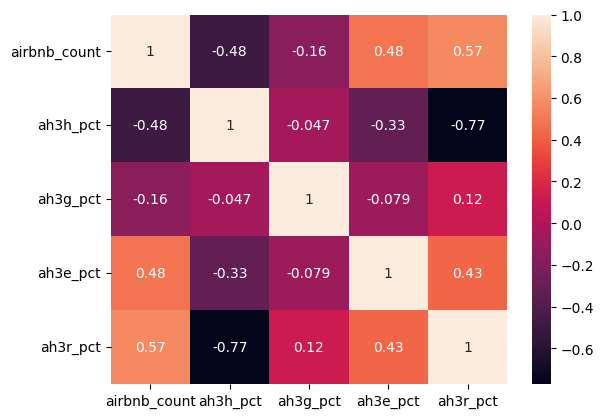

In [ ]:
# visualise Spearman's rank correlations
sns.heatmap(ahah_domains_corr, annot=True)

<Axes: >

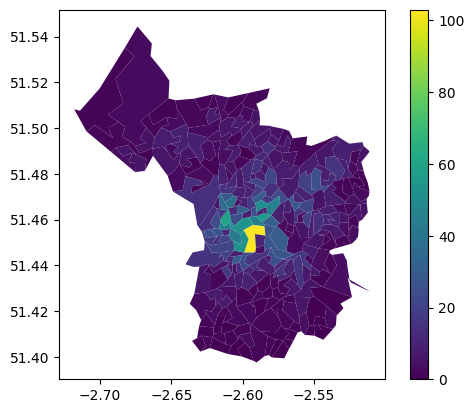

In [ ]:
# explore the spatial distribution of Airbnb listings
ahah_airbnb.plot(column='airbnb_count', legend=True)

<Axes: >

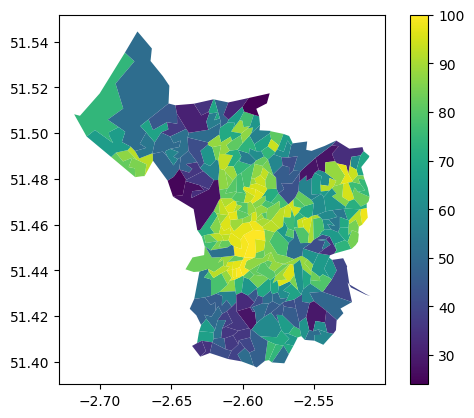

In [ ]:
# explore the spatial distribution of the Retail Domain percentile
ahah_airbnb.plot(column='ah3r_pct', legend=True)

In [ ]:
# calculate Spearman's rank correlations for the Retail components
retail_corr = ahah_airbnb[
    ['airbnb_count', 'ah3ffood_pct', 'ah3gamb_pct', 'ah3pubs_pct', 'ah3tob_pct']
].corr(method='spearman')

retail_corr

,airbnb_count,ah3ffood_pct,ah3gamb_pct,ah3pubs_pct,ah3tob_pct
airbnb_count,1.000000,0.507771,0.154533,0.719788,0.293404
ah3ffood_pct,0.507771,1.000000,0.568027,0.750033,0.534841
ah3gamb_pct,0.154533,0.568027,1.000000,0.414342,0.298919
ah3pubs_pct,0.719788,0.750033,0.414342,1.000000,0.485478
ah3tob_pct,0.293404,0.534841,0.298919,0.485478,1.000000


In [ ]:
# select the correlations between Airbnb listings and Retail components
retail_correlations = retail_corr.loc[
    'airbnb_count',
    ['ah3ffood_pct', 'ah3gamb_pct', 'ah3pubs_pct', 'ah3tob_pct']
]

retail_correlations

,airbnb_count
ah3ffood_pct,0.507771
ah3gamb_pct,0.154533
ah3pubs_pct,0.719788
ah3tob_pct,0.293404


In [ ]:
# rename the Retail components for readability
retail_correlations.index = [
    'Fast food outlets',
    'Gambling outlets',
    'Pubs/Bars/Nightclubs',
    'Vape stores/Tobacconists'
]

retail_correlations

,airbnb_count
Fast food outlets,0.507771
Gambling outlets,0.154533
Pubs/Bars/Nightclubs,0.719788
Vape stores/Tobacconists,0.293404


2.Methodology

2.1	Data

The study used two sets of data. One was the Airbnb data from Bristol, and the other was the "Access to Healthy Assets and Hazards" (AHAH) data from Bristol.

2.1.1 Airbnb's data

Airbnb is a well-known accommodation platform where individual hosts can list their properties for rent. Tourists can choose from the listings on the platform. Airbnb acts as the intermediary and charges a fee from both parties <a href="#ref2">[2]</a>. The Airbnb data comes from GEOG5990M final project resit project. This dataset contains 28 columns and over 2,500 accommodation information entries. It records the location and basic attributes of the housing units.

2.1.2 The AHAH data

AHAH is the "Index of 'Access to Healthy Assets and Hazards'", which is an index developed by the British Geographical Data Service <a href="#ref6">[6]</a>. This dataset has 68 columns and over 260 pieces of information. The 68 columns of the dataset mainly evaluate the health characteristics of the surrounding environment of each LSOA in four major directions: Retail environment, Health services, Physical environment, and Air quality. The higher the score, the worse the community's health condition.

2.2	Data Preparation and Exploration

By examining the Airbnb data, it was found that there were many missing values. The missing data accounted for 2556 entries, indicating that this content was not included in the overall statistics. It is possible to combine the two datasets with the code 'LSOA11CD', as one of the rows has missing data. Upon checking this row, it was found that it was merely a lack of statistics, not an abnormal data point. This can be disregarded and not included in the calculation among over 2000 data entries.

By examining the AHAH data, it was discovered that this data is intact and has no missing values. It is suitable as an analysis object.

Count the number of Airbnb rentals in each LSOA, obtaining 245 pieces of data. This indicates that there are 18 LSOAs without any rental listings. Combine the two sets of data using LSOA11CD. At this point, the data without missing LSOAs is removed. It cannot be assigned to any LSOA and cannot participate in the regional-level analysis. Therefore, it is excluded during the aggregation process.

LSOAs without matching Airbnb records have missing values. Since these missing values represent that there are no Airbnb listings in those LSOAs, they are not data missing. Replace the missing data in LSOAs without rentals with 0.

2.3	Exploratory and Statistical Analysis

2.3.1
the number of Airbnb listings and the AHAH comprehensive score.


The number of Airbnb listings shows a clearly right-skewed distribution, with a median of 6 and a maximum of 103. This indicates that the majority of LSOAs have a relatively small number of Airbnb listings, while a few regions have a high concentration. For continuous data that does not follow a normal distribution, the Spearman method can be used, and the Spearman method is relatively robust to outliers <a href="#ref7">[7]</a>. Spearman's rank correlation was chosen to study these two sets of data.

Spearman's ρ is approximately 0.3, indicating a positive correlation.

2.3.2

the number of Airbnb listings and the scores in the four directions of AHAH.
Retail environment was positively correlated, Air quality was positively correlated, Health services was negatively correlated, while Green/Blue space showed little relationship.

2.3.3

the number of Airbnb accommodations and the scores in the four aspects of the retail environment
Select Spearman's rank correlation to study these five data. Spearman's ρ indicates that the accessibility of Pubs/Bars/Nightclubs is the most relevant to the number of accommodations, with Spearman's ρ approximately equal to 0.7, followed by the accessibility of Fast food, with Spearman's ρ approximately equal to 0.5. The relationship between the number of Airbnb accommodations and the accessibility to gambling facilities and tobacco stores is not significant. Change the name.

In [ ]:
import matplotlib.pyplot as plt

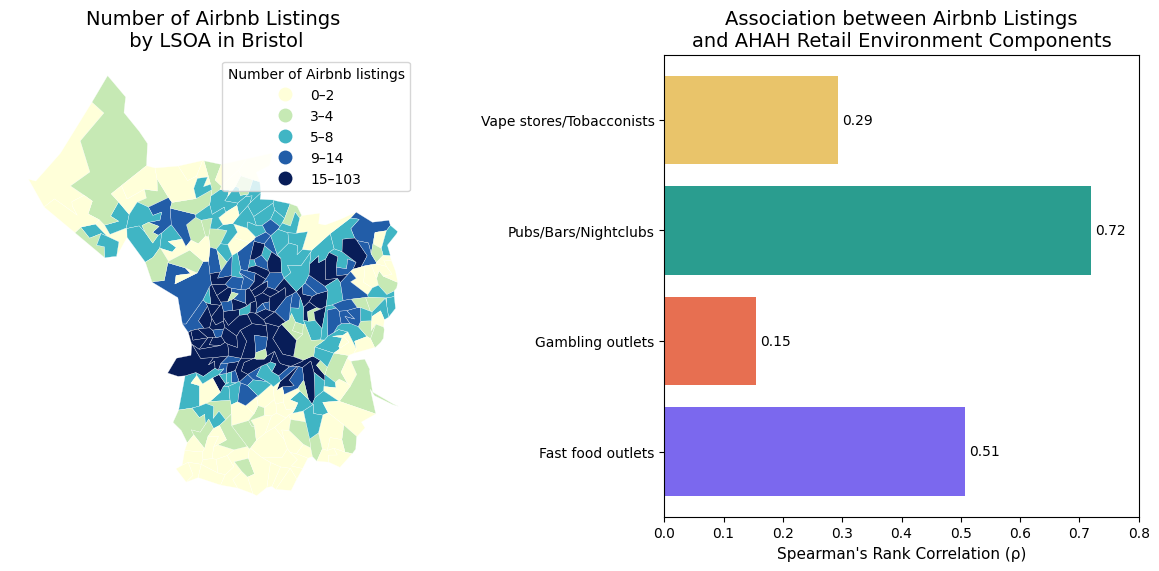

In [ ]:
# create the two final visualisations
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# spatial visualisation
ahah_airbnb.plot(
    ax=ax[0],
    column='airbnb_count',
    legend=True,
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    edgecolor='white',
    linewidth=0.2
)
# add a title to the map legend
ax[0].get_legend().set_title('Number of Airbnb listings')

# make the legend labels easier to read
legend = ax[0].get_legend()

labels = [
    '0–2',
    '3–4',
    '5–8',
    '9–14',
    '15–103'
]

for text, label in zip(legend.get_texts(), labels):
    text.set_text(label)

# map title
ax[0].set_title(
    'Number of Airbnb Listings\n by LSOA in Bristol',
    fontsize=14
)

# remove map axes
ax[0].set_axis_off()

# non-spatial visualisation
bars = ax[1].barh(
    retail_correlations.index,
    retail_correlations.values,
    color=['#7B68EE', '#E76F51', '#2A9D8F', '#E9C46A']
)

# bar chart title
ax[1].set_title(
    'Association between Airbnb Listings\nand AHAH Retail Environment Components',
    fontsize=14
)

# axis label
ax[1].set_xlabel(
    "Spearman's Rank Correlation (ρ)",
    fontsize=11
)

# add correlation values to the bars
ax[1].bar_label(
    bars,
    fmt='%.2f',
    padding=3
)

# leave space for the value labels
ax[1].set_xlim(0, 0.8)

# make text easier to read
ax[1].tick_params(axis='y', labelsize=10)
ax[1].tick_params(axis='x', labelsize=10)

# add some space between the two visualisations
plt.subplots_adjust(wspace=0.45)

plt.show()


In [ ]:
#A larger positive Spearman's ρ indicates a stronger positive association between the number of Airbnb listings and the retail environment indicator. Higher AHAH percentiles indicate less healthy environments in terms of expected health impacts.

3.result


3.1 Spatial map

The "YlGnBu" color scheme was selected for the quintile stratified color map. The map shows that the spatial distribution of Airbnb accommodations in Bristol is not uniform. From the map, it can be seen that there are fewer accommodations in the northwest and south areas, and the number of accommodations increases as one gets closer to the city center. Moreover, the accommodations are concentrated in many areas, with a maximum of 103.

3.2Non-spatial chart

From the horizontal bar chart, it can be seen that among the four constituent indicators of the Retail Environment, the number of Pubs/Bars/Nightclubs and Airbnb accommodations shows the strongest positive correlation (ρ = 0.72), followed by Fast food outlets (ρ = 0.51). According to the definition of AHAH, a higher percentile indicates a relatively less healthy environment in terms of expected health impacts. Therefore, the results suggest that LSOA with a higher number of Airbnb accommodations tend to have higher percentiles in some Retail Environment indicators.


4.Disccusion

4.1 Intended Audience

Audience: Airbnb hosts and guests, government departments responsible for tourism, urban planning or short-term rental management

4.2. Visualisation Choices

4.2.1Spatial map

If the quintile-based layering color map is not set, since the number of accommodations in one of LSOA is much higher than that of others, in the gradient-colored map, only that one LSOA can be seen. The other LSOAs have similar colors because the differences in their values are relatively small. If it is a blue-white gradient, the edge LSOAs will all turn white and have no difference from the background, making it impossible to intuitively see the differences between LSOAs with 0 to 15 accommodations. The quintile classification can make the spatial differences between different LSOAs more easily displayed.

Selecting the "YlGnBu" color scheme, there is a gradual change from light to dark colors, with light colors representing low values and dark colors representing high values. And there are different color changes, the lightest color is not white, and it is different from the background color, making it easier to see clearly.

4.2.2Non-spatial chart

Because the names of the four categories are too long, if it is a vertical bar chart, the category names should be written slantwise. Choose a horizontal bar chart for display. The colors of the horizontal bar chart are different, and the values can directly indicate. The number of accommodations and the accessibility to bars are positively correlated in the LSOA.

4.3 Limit

The authors who created the AHAH index found that areas with good health environment performance are concentrated in the peripheral areas of the urban core, while areas with poor health environment performance are located in the city center and rural areas <a href="#ref8">[8]</a>. The tourist attractions in Bristol are concentrated in the Old City, Harbourside, and the central area of Clifton <a href="#ref9">[9]</a>. The correlation between Airbnb listings and some AHAH indicators may be influenced by common spatial location factors. These two data are related, but it does not mean a causal relationship.

This study is conducted at the LSOA level. There is still space within an LSOA. Higher Airbnb numbers and higher Pubs/Bars/Nightclubs percentiles occur simultaneously in the same LSOA. This can only indicate an association at the regional level, not that Airbnb accommodations are adjacent to bars.



5.conclusion

This study investigated the relationship between the number of Airbnb listings in each LSOA of Bristol and the environmental characteristics of AHAH. Airbnb showed a significant spatial concentration. Among them, the Retail Environment had the strongest positive correlation with the number of Airbnb listings, and among the constituent indicators, the correlation of Pubs/Bars/Nightclubs was the highest (ρ ≈ 0.7). The findings may inform local short-term rental and tourism management. However, the correlation does not imply causation. In the future, more specific analyses can be conducted by including factors such as the distribution of tourist attractions and the distance to the city center that attract tourists.

Do not forget to attach the link to your GitHub repo within your submitted zip file.



## References
<p><a href="add_url_here">[1]</a>Voltes-Dorta, A. and Sánchez-Medina, A. Drivers of Airbnb prices according to property/room type, season and location: A regression approach. <i>Journal of Hospitality and Tourism Management.</i> [Online]. 2020, 45, pp.266-275. [Accessed 25 August 2026]. Available from:
https://www.sciencedirect.com/science/article/pii/S1447677020302023</p>
<p><a href="https://github.com/FrancescaPontin/GEOG5990">[2]</a>Guttentag, D. Progress on Airbnb: a literature review. <i>Journal of Hospitality and Tourism Technology.</i> [Online]. 2019, 10(4), pp.814-844. [Accessed 25 August 2026]. Available from:
https://www.proquest.com/docview/2289421047?accountid=14664&pq-origsite=primo&sourcetype=Scholarly%20Journals</p>
<p><a href="add_url_here">[3]</a>Voltes-Dorta, A. and Inchausti-Sintes, F. The spatial and quality dimensions of Airbnb markets. <i>Tourism Economics: The Business and Finance of Tourism and Recreation.</i> [Online]. 2021, 27(4), pp.688-702. [Accessed 25 August 2026]. Available from: https://journals.sagepub.com/doi/abs/10.1177/1354816619898075</p>
<p><a href="add_url_here">[4]</a>Public Health England. <i>Spatial planning for health: an evidence resource for planning and designing healthier places.</i> [Online]. London: Public Health England, 2017. [Accessed 26 August 2026]. Available from: https://www.gov.uk/government/publications/spatial-planning-for-health-evidence-review</p>
<p><a href="add_url_here">[5]</a>Geographic Data Service. <i>Access to Healthy Assets & Hazards (AHAH).</i> [Online]. [Accessed 26 August 2026]. Available from: https://data.geods.ac.uk/dataset/access-to-healthy-assets-hazards-ahah</p>
<p><a href="add_url_here">[6]</a>Green, M.A., Daras, K., Davies, A., Barr, B. and Singleton, A. Developing an openly accessible multi-dimensional small area index of ‘Access to Healthy Assets and Hazards’ for Great Britain, 2016. <i>Health & Place.</i> [Online]. 2018, 54, pp.11-19. [Accessed 25 August 2026]. Available from: https://www.sciencedirect.com/science/article/pii/S1353829218303563</p>
<p><a href="add_url_here">[7]</a>Schober, P., Boer, C. and Schwarte, L.A. Correlation coefficients: appropriate use and interpretation. <i>Anesthesia & Analgesia.</i> [Online]. 2018, 126(5), pp.1763-1768. [Accessed 26 August 2026]. Available from: https://ovidsp.dc1.ovid.com/ovid-new-b/ovidweb.cgi?QS2=434f4e1a73d37e8cddef71afa9dd4550a3d283fbbd197ce17e8262e5e3457118aac0cce3877cc4ed272468c283f147d03d98a1e03c8ba4f625bb425ce506f32276d4fec54c09b009730fd5f0ac06390b38eeb2b2639680ca5d5f8e2ad5bd583c46d52614572dd6327e66d732912454414b05e8874c4e7893a1be26308b552b015d07c47b75ad243d375a6c56cc3dd66e105670a6d6bb50c7497151a87d478e4d7c5d6fe239541205e5a21942f29e2b05bd1bcaa73f576faaa26350b0ab14d70d150be8b1b63c2bd31f690166417b25a33cbeeb5fce4d83621bec45bd43446154df2c463cf302b8fde541540404d2c63c867a09288fdfbe268b2d08a6c82ed6df32c98c0b5efc2ceeeedf9e4f3cfa823b17c138d32ed138e8e3bae6d53cf04949796aaa0d28b59055554de85e6eecf835cf5b152efa57e7a7b2aa7db788c627b463925c1aeeef5401d19a72473b76344e0083dc75900614d202b51fccaf6c51d8d57e1759463c7f0b3364cfcb869ffe7e86e3d7c57a687b39a1af2c58c1608bbd275518730dffec6e7636b81b6fc7ed76f23d63f2095baf9d</p>
<p><a href="add_url_here">[8]</a>Daras, K., Green, M.A., Davies, A., Barr, B. and Singleton, A. Open data on health-related neighbourhood features in Great Britain. <i>Scientific Data.</i> [Online]. 2019, 6(1). [Accessed 26 August 2026]. Available from: https://pmc.ncbi.nlm.nih.gov/articles/PMC6602943/</p>
<p><a href="add_url_here">[9]</a>Visit West. <i>Maps and guides.</i> [Online]. 2026. [Accessed 26 August 2026]. Available from: https://visitbristol.co.uk/plan-your-visit/maps/</p>


<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>